## The Heart Disease Dataset — A Medical Translation Guide
### What this dataset actually is
This is a changed copy of the Cleveland Heart Disease dataset (UCI ML Repository, the most famous heart-disease dataset in ML — thousands of papers use it). 303 patients, 13 measurements + 1 target. Each row is one patient who was referred for a diagnostic workup because of suspected heart problems.

This is a referral population of already-sick people, not the general population. Therefore this EDA make no sense from a "general health" viewpoint.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import numpy as np
import seaborn as sns


import matplotlib.colors as mcolors


In [2]:
df = pd.read_csv("heart.csv")

print("--- First 5 samples ---")
display(df.head())

c = list(df.columns)
size = df.shape
print(f"size : {size}")
print("List of features:")
print(f"{c}\n")
print(f"This dataset has {size[0]} samples with {len(c)-1} features and 1 target column.")


# let's categorize columns

binary_columns = ['sex','fbs','exang','target']
categorical_columns = ['cp', 'restecg', 'slope','ca', 'thal']
continous_columns = ['age', 'trestbps', 'chol','thalach', 'oldpeak']

--- First 5 samples ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


size : (303, 14)
List of features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

This dataset has 303 samples with 13 features and 1 target column.


### My General understading of features
- `trestbps` (blood pressure) — high pressure physically damages the artery walls, making plaque more likely to lodge there
- `chol` (cholesterol) — the raw material of the plaque itself
- `cp` (chest pain) — the heart muscle's distress signal when it's not getting enough oxygen
- `thalach` (max heart rate), `exang` (exercise angina), `oldpeak` + `slope` (ST-segment changes) — a stress test: make the heart work hard and watch whether it runs out of oxygen (→ chest pain, abnormal ECG)
- `ca` (blocked vessels seen on X-ray) — the plaque itself, directly imaged
- `thal` (thallium scan) — whether heart muscle is alive but starved (reversible defect) or already dead (fixed defect = prior heart - attack)
- `restecg`, `fbs` — pre-existing damage and metabolic risk factors
- `age`, `sex` — the two things you cannot change


## Missing Values :
We can conlcude from the count of samples for each feature that there is no missing data of type **NAN** in this dataset.
However, we should still check for other types of missing data and also outliers.

In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Investigating Continuous features

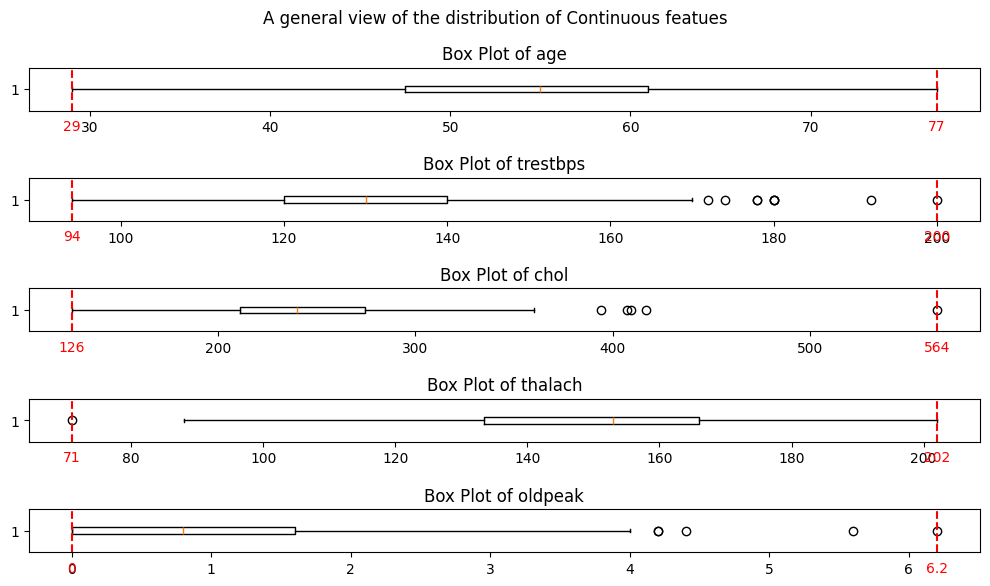

In [4]:
fig, axes = plt.subplots(len(continous_columns),1,figsize=(10,6))

axes = axes.flatten()

for ax, col in zip(axes, continous_columns):
    data=df[col].dropna()
    ax.boxplot(data, vert=False)
    
    min_val = min(data)
    max_val = max(data)
    
    ax.axvline(min_val,c="red",linestyle="--")
    ax.axvline(max_val,c="red",linestyle="--")
    
    
        # Add min/max values on the x-axis
    ax.text(
        min_val,
        -0.20, # for y axis
        f"{min_val:g}", # g for general format (12.34 - > 12.34 but 12.0 -> 12 )
        color="red",
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform() #Use data coordinates for X, but axis-relative coordinates for Y.
    )

    ax.text(
        max_val,
        -0.20,
        f"{max_val:g}",
        color="red",
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform()
    )
    
    ax.set_title(f"Box Plot of {col}")

fig.suptitle("A general view of the distribution of Continuous featues")
plt.tight_layout()
plt.show()


## What I understood so far from checking the ranges of these feature:
- The population `age` range is 29 to 77. So the dataset has been collected from adults and does not contain children and teenagers.

- The range for `trestbps` which is resting blood pressure (systolic), measured in mm Hg For adults is:

|  trestbps | Interpretation     |
| ----------: | ------------------ |
|    **< 90** | Low                |
|  **90–119** | Normal             |
| **120–129** | Elevated           |
| **130–139** | High               |
| **140–179** | Hypertension, high |
|   **≥ 180** | Severely high      |

A practical range for real human measurements would be approximately: **70–250 mm Hg** -> Data looks fine.

- The range of the feature `chol` which is the Serum cholesterol(mg/dL) is NOT valid. NEEDS FURTHER EXPLORATION!

| Total cholesterol | Interpretation                        |
| ----------------- | ------------------------------------- |
| **< 200 mg/dL**   | Desirable                             |
| **200–239 mg/dL** | Borderline high                       |
| **≥ 240 mg/dL**   | High                                  |
|      300–399      | Very high, but plausible              |
|      400–499      | Extremely high, uncommon but possible |         
|     **500+**      | Very unusual                          |

-  The valid range for `thalach` (maximum heart rate achieved during the exercise test) measured in beats per minute (bpm) 

For adults, a practical interpretation is:
| thalach (bpm) | Interpretation                 |
| --------------: | ------------------------------ |
|        **< 50** | Very unusual                   |
|      **50–100** | Low, but possible              |
|     **100–150** | Common                         |
|     **150–200** | Common during exercise testing |
|     **200–220** | High but possible              |
|       **> 220** | Very unusual                   |

So my data looks fine.

- `oldpeak` ST-segment depression induced by exercise relative to rest, measured in mV valid range:

| oldpeak | Interpretation                               |
| --------: | -------------------------------------------- |
|   **0–1** | Common                                       |
|   **1–2** | Common                                       |
|   **2–4** | High, but plausible                          |
|   **4–6** | Very high, uncommon but possible             |
|   **> 6** | Extremely unusual                            |



## Investgate `chol` and `oldpeak` for outliers

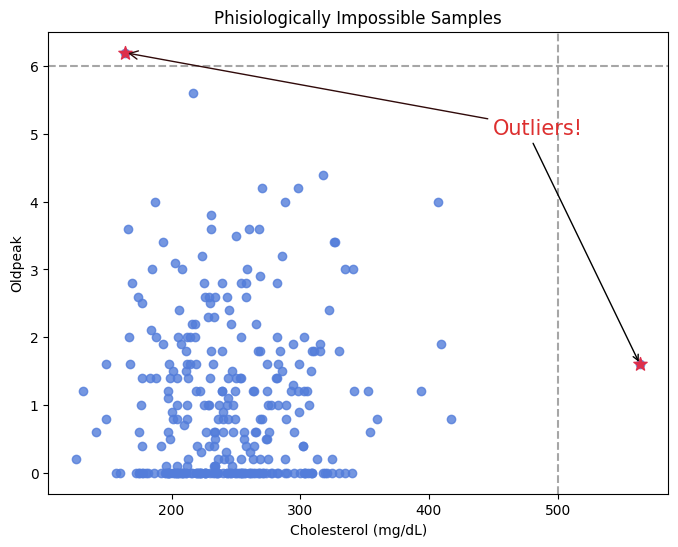

These two samples will be deleted from the dataframe.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
204,62,0,0,160,164,0,0,145,0,6.2,0,3,3,0


 The updated dataframe has 303-2 = 301  samlpes


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df["chol"],df["oldpeak"],color="#537DDA",alpha=0.8)

#outliers
outlier_1 = df["oldpeak"] > 6
outlier_2 = df["chol"] > 500

ax.scatter(df.loc[outlier_1, "chol"],df.loc[outlier_1, "oldpeak"],color="#DD2F4C",s=100,marker="*",zorder=3)
ax.scatter(df.loc[outlier_2, "chol"],df.loc[outlier_2, "oldpeak"],color="#DD2F4C",s=100,marker="*",zorder=3)

# Vertical and horizontal reference lines
ax.axvline(500, color="gray", linestyle="--", alpha=0.7)
ax.axhline(6, color="gray", linestyle="--", alpha=0.7)

# "outliers!" text + arrow to first outlier
ax.annotate(
    "Outliers!",
    xy=(df.loc[outlier_1, "chol"].iloc[0],
        df.loc[outlier_1, "oldpeak"].iloc[0]),
    xytext=(450, 5),
    arrowprops=dict(arrowstyle="->", color="#300A0A"),
    fontsize=15,
    color="#DD2F2F"
)

# Second arrow from the same text position
ax.annotate(
    "",
    xy=(df.loc[outlier_2, "chol"].iloc[0],
        df.loc[outlier_2, "oldpeak"].iloc[0]),
    xytext=(480, 4.9),
    arrowprops=dict(arrowstyle="->")
)

ax.set_xlabel("Cholesterol (mg/dL)")
ax.set_ylabel("Oldpeak")
ax.set_title("Phisiologically Impossible Samples")
plt.show()

outliers = outlier_1| outlier_2
print("These two samples will be deleted from the dataframe.")
display(df.loc[outliers])


# make a dataframe without outliers
df_new = df.loc[~outliers].copy()
print(f" The updated dataframe has {df.shape[0]}-{len(df.loc[outliers])} = {df_new.shape[0]}  samlpes")


## Investigating Categorial features


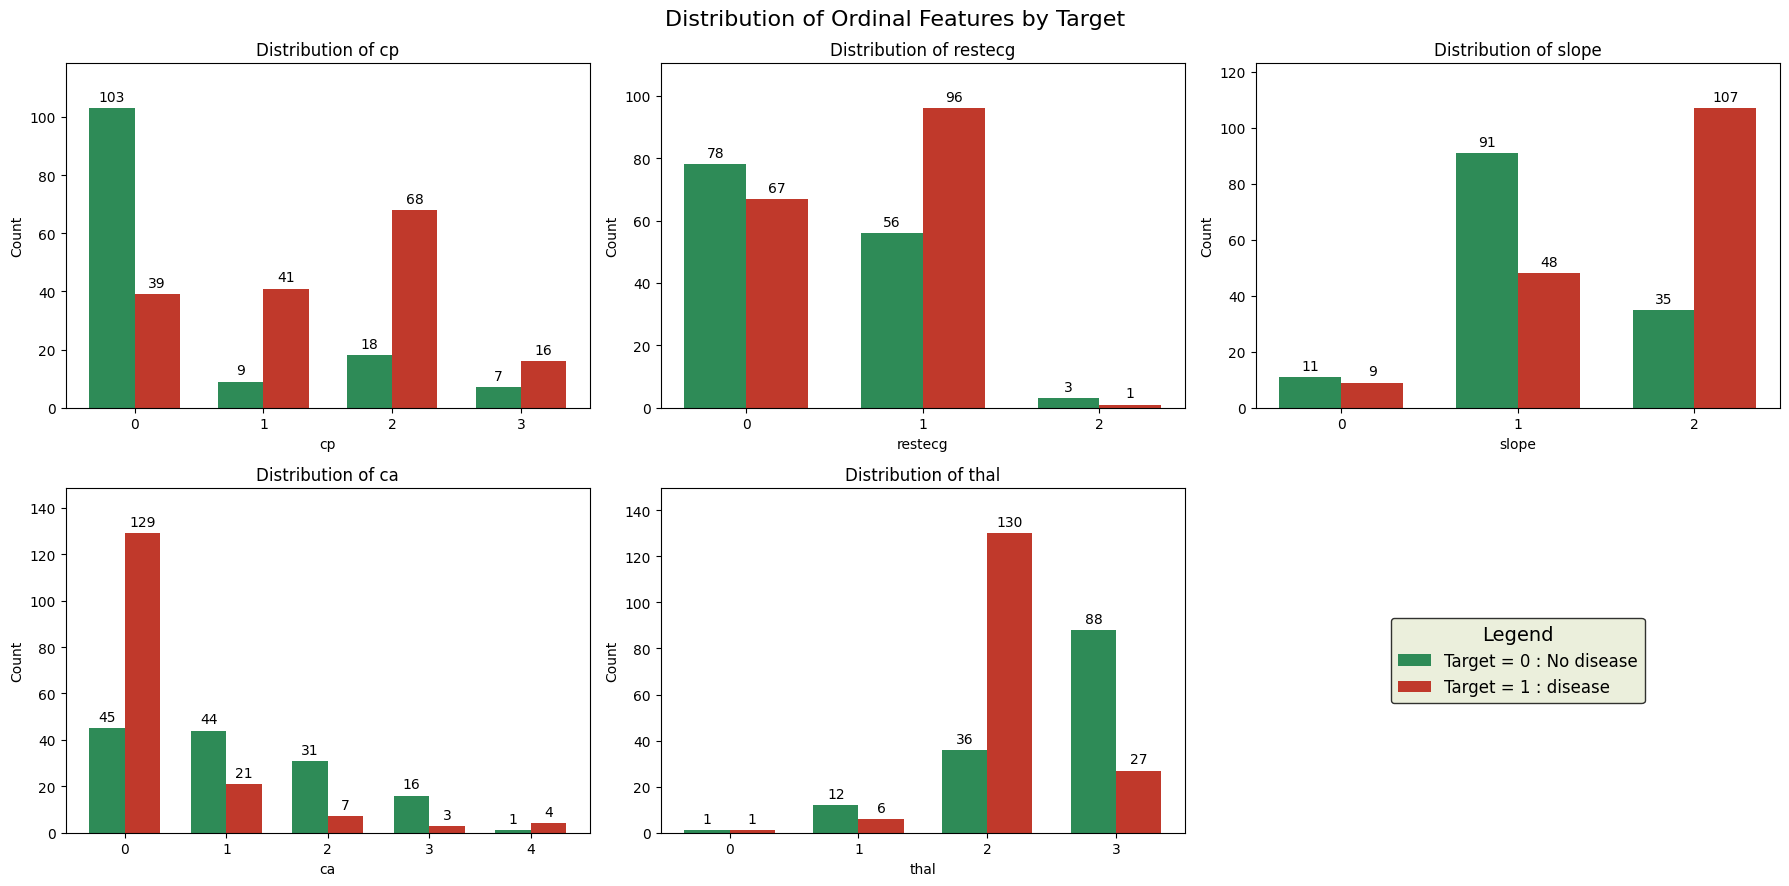

In [6]:
categorical_columns = ['cp', 'restecg', 'slope', 'ca', 'thal']

colors = {"no_disease": "#2E8B57", "disease": "#C0392B"}


fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes[:-1], categorical_columns):

    # Count each category separately for target=0 and target=1
    counts_0 = df_new[df_new["target"] == 0][col].value_counts().sort_index()
    counts_1 = df_new[df_new["target"] == 1][col].value_counts().sort_index()

    # All categories that exist in either target group
    categories = sorted(set(counts_0.index) | set(counts_1.index))

    # Get counts, using 0 if a category doesn't exist for one target
    values_0 = [counts_0.get(category, 0) for category in categories]
    values_1 = [counts_1.get(category, 0) for category in categories]

    # Positions of the categories
    x = np.arange(len(categories))

    # Width of each bar
    width = 0.35

    # Two bars side by side
    bars_0 = ax.bar(
        x - width/2,
        values_0,
        width,
        color=colors["no_disease"],
        label="Target = 0"
    )

    bars_1 = ax.bar(
        x + width/2,
        values_1,
        width,
        color=colors["disease"],
        label="Target = 1"
    )

    # Add numbers above each bar
    ax.bar_label(bars_0, padding=3)
    ax.bar_label(bars_1, padding=3)

    # X-axis
    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {col}")

    # Make some room above bars for the labels
    ax.set_ylim(0, max(values_0 + values_1) * 1.15)


# Sixth subplot: legend only
axes[-1].axis("off")
legend_ax=axes[-1]

legend_ax.legend(
    handles=[bars_0, bars_1],
    labels=["Target = 0 : No disease", "Target = 1 : disease"],
    loc="center",
    fontsize=12,
    frameon=True,
    edgecolor="black",
    title="Legend",
    facecolor = "#E7ECD4",
    title_fontsize=14
)


fig.suptitle("Distribution of Ordinal Features by Target", fontsize=16)

plt.tight_layout()
plt.show()

## One by one exploration of categorical features:

### cp

|  `cp` | Chest pain type  | Meaning                                                          |
| ----: | ---------------- | ---------------------------------------------------------------- |
| **0** | Typical angina   | Chest pain with the characteristics of classic angina            |
| **1** | Atypical angina  | Chest pain that does not meet all the typical features of angina |
| **2** | Non-anginal pain | Chest pain that is not considered typical of cardiac ischemia    |
| **3** | Asymptomatic     | No chest pain/symptoms reported                                  |

In general, typical angina (cp=0) is **strongly associated** with coronary heart disease, while the other categories are less directly indicative.

- In the plot of `cp` we see that there are 103 data points that are considered healthy while they have cp=0 which is the most suggestive of disease! THIS IS SUSPICIOUS!

### `restecg`

| `restecg` | Category                           | What it means                          | Association with disease                           |
| --------: | ---------------------------------- | -------------------------------------- | -------------------------------------------------- |
|     **0** | Normal                             | Normal resting ECG                     |  Generally more common in people without disease   |
|     **1** | ST-T wave abnormality              | Abnormal ST-T wave changes             |  More suggestive of disease                        |
|     **2** | Left ventricular hypertrophy (LVH) | ECG shows findings consistent with LVH |  Can be associated with disease                    |

- From the definitions in the table, I generally expect the **restecg = 0** category to be more common among people with `target = 0` (no disease). 
-  For  **restecg = 1** to potentially have a higher proportion of target = 1 .Data looks fine for now!

### `slope`

| `slope` | Category    | Meaning                               | General association with disease |
| ------: | ----------- | ------------------------------------- | -------------------------------- |
|   **0** | Upsloping   | ST segment rises during peak exercise |  Generally less concerning       |
|   **1** | Flat        | ST segment remains relatively flat    |  More associated with disease    |
|   **2** | Downsloping | ST segment falls during peak exercise |  More concerning                 |

- From the definitions in the table, I can expect to see more diseased than healthy in `slope = 2`. Data looks fine!

### `ca`

Fluoroscopy = live X-ray with dye injected into the coronaries (angiography). This is the most direct measurement of the disease itself — you're literally counting blocked arteries. **It's a diagnostic oracle, not a risk factor:** in clinical reality, you'd only order this invasive test because you **already suspect disease**. **`ca` does not cause the disease. It measures it.**

|  `ca` | Meaning                  | General association with disease    |
| ----: | ------------------------ | ----------------------------------- |
| **0** | No major vessels colored |    Generally lower likelihood       |
| **1** | 1 major vessel colored   |    Higher likelihood                |
| **2** | 2 major vessels colored  |    Higher likelihood                |
| **3** | 3 major vessels colored  |    Strongly associated with disease |

- The data is **highly suspicous** here. I expect to see more healthy people that diseased in the caetgory `ca = 0`, but the plot shows 129 diseased and only 45 healthy samples.
- for other categories ca= 1, 2, 3 I  can not really imagine healthy people with this many blocked vessels :) . The plot shows `44+ 31+ 16 = 91` healthy people in these categories that **do NOT** make much sense to me. But I am going to keep them.
- for the last category `ca = 4`, I am going to **confidently delete the 1 data point** that has target value of 0. I consider it wrong data point ( How can someone with 4 vessels blocked be considered healthy???)


### `thal`
**reversible defect** = alive but starved (the exact condition disease causes) 
**fixed defct** = already dead tissue (prior attack)

| `thal` | Meaning                                           | General association with disease          |
| -----: | ------------------------------------------------- | ----------------------------------------- |
|  **0** | Normal                                            |   Generally less associated with disease  |
|  **1** | Fixed defect                                      |   Associated with disease                 |
|  **2** | Reversible defect                                 |   Strongly associated with disease        |
|  **3** | Not described                                     |   I do not know anything!                 | 

 - Data looks fine.

In [7]:
## delete the 1 outlier found from the analysis of individual categorial features
healthy_ca4 = (df_new["ca"] == 4) & (df_new["target"] == 0)
print(" The one sample that I want to delete:")
display(df_new.loc[healthy_ca4])

df_new = df_new.drop(df_new.loc[healthy_ca4].index).copy()

print(f"A total of 3 samples have been deleted so far and {df_new.shape[0]} samples are left.")

 The one sample that I want to delete:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
251,43,1,0,132,247,1,0,143,1,0.1,1,4,3,0


A total of 3 samples have been deleted so far and 300 samples are left.


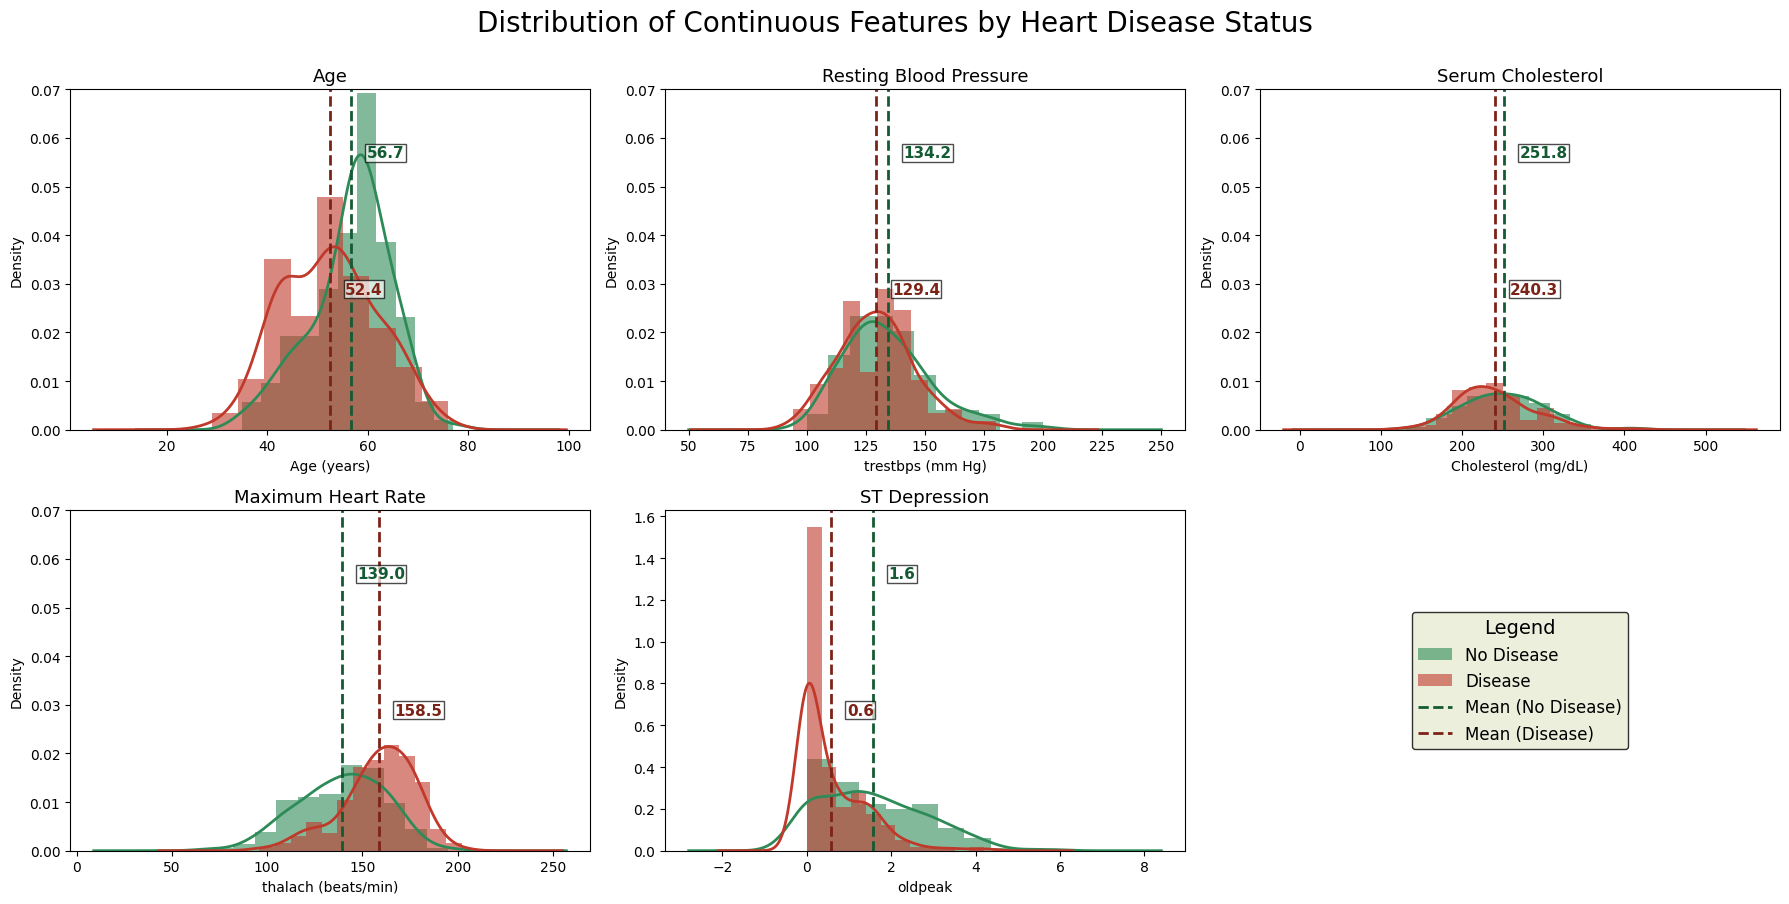

In [11]:
# Display names
titles = {
    "age": "Age",
    "trestbps": "Resting Blood Pressure",
    "chol": "Serum Cholesterol",
    "thalach": "Maximum Heart Rate",
    "oldpeak": "ST Depression"
}

# Axis labels (with units)
xlabels = {
    "age": "Age (years)",
    "trestbps": "trestbps (mm Hg)",
    "chol": "Cholesterol (mg/dL)",
    "thalach": "thalach (beats/min)",
    "oldpeak": "oldpeak"
}

fig, axes = plt.subplots(2,3,figsize=(18,9))

axes = axes.flatten()

for ax, col in zip(axes[:-1], continous_columns):

    no_disease = df_new.loc[df["target"] == 0, col]
    disease = df_new.loc[df["target"] == 1, col]

    mean_no = no_disease.mean()
    mean_yes = disease.mean()

    # Histograms
    ax.hist(no_disease, bins="auto", density=True, alpha=0.6, color=colors["no_disease"])
    ax.hist(disease, bins="auto", density=True, alpha=0.6, color=colors["disease"])

    # KDE
    no_disease.plot.kde(ax=ax, color=colors["no_disease"],linewidth=2)
    disease.plot.kde(ax=ax, color=colors["disease"],linewidth=2)

    # Mean lines
    ax.axvline(mean_no, color="#145A33", linestyle="--",linewidth=2)
    ax.axvline(mean_yes, color="#7C2317", linestyle="--",linewidth=2)

    # Common y-axis for all except oldpeak -> so that I cna compare densities of different features
    if col != "oldpeak":
        ax.set_ylim(0, 0.07)

    # Mean values beside the lines
    ylim = ax.get_ylim()
    text_y_no = ylim[1]* 0.8
    text_y_yes = ylim[1]* 0.4
    offset_x = 0.03 * (ax.get_xlim()[1] - ax.get_xlim()[0])

    ax.text(
        mean_no + offset_x,
        text_y_no,
        f"{mean_no:.1f}",
        color="#145A33",
        # rotation=90,
        # ha="right",
        # va="top",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
    facecolor="white",
    edgecolor="black",
    alpha=0.7,
    pad=1
    )
    )

    ax.text(
        mean_yes + offset_x,
        text_y_yes,
        f"{mean_yes:.1f}",
        color="#7C2317",
        # rotation=90,
        # ha="left",
        # va="top",
        fontsize=11,
        fontweight="bold",
    bbox=dict(
    facecolor="white",
    edgecolor="black",
    alpha=0.7,
    pad=1
    )
    )

    ax.set_title(titles[col], fontsize=13)
    ax.set_xlabel(xlabels[col])
    ax.set_ylabel("Density")


# ---------- Legend Panel ----------

legend_ax = axes[-1]
legend_ax.axis("off")

legend_items = [

    Patch(facecolor=colors["no_disease"],
          alpha=0.6,
          label="No Disease"),

    Patch(facecolor=colors["disease"],
          alpha=0.6,
          label="Disease"),

    Line2D([0],[0],
           color="#145A33",
           linestyle="--",
           linewidth=2,
           label="Mean (No Disease)"),

    Line2D([0],[0],
           color="#7C2317",
           linestyle="--",
           linewidth=2,
           label="Mean (Disease)")
]

legend_ax.legend(
    handles=legend_items,
    loc="center",
    fontsize=12,
    frameon=True,
    edgecolor="black",
    title="Legend",
    facecolor = "#E7ECD4",
    title_fontsize=14
)

fig.suptitle("Distribution of Continuous Features by Heart Disease Status",fontsize=20, y=1)

plt.tight_layout()
plt.show()

### From this I can understand that most probably the target lablels are vice versa! If we change it , it will make sense!

- I have intentionally added histograms in addition to KDE because KDE tends to oversmoothen the data distribution, So this way I have a better understanding of the data.
- In the plot above, I have set the y axis range the same on the first 4 plots to be able to actually compare their densities. I excluded ST depression because as you can see from the range of the y asix (0 - 1.6) in it's density, it has a very concentrated distribution around 0.
- Among the first 4 plots, you can see that **Age** has the most concentrated distribution (reached 0.07 in the density for at the highest), after that we have **Resting blood pressure** and **Max hear rate** with the peaks of around 0.03 in the distributions (less concentranted than age among samples). The most spare and least concentrated feature among all continuous features is **Serum Cholestrol** which has a way smoother and not condensed distribution (peak around 0.01).
- All these features have a normal like distribution, with **Max heart rate** and **St depression** have skewness to left and right respectively.
- I'd like to derive your attention to the vertical lines in each plot that show the mean values. There are some surprising results found :
    - the average age of  people with diseased heart is **4.3** years **younger** than the hearts with no disease.
    - people with diseased heart tend to have lower **Resting blood pressure**, **Serum Cholesterol** and **ST depression** levels, but higher heart rate!

#### The findings from here could generally suggest that the target column labels should be the opposite. But this is not something I would do, because it is just based on the continous columns and I alreay explored that the target made good sense in terms of categrial features.

## Explore the features coming from stress test  (a.k.a. "exercise ECG") together,

| Column | Meaning | Gotchas |
|---|---|---|
| **thalach** | Max heart rate achieved during the test (71–202 bpm) | A higher `thalach` is **good** — it means the heart can work hard. If the test has to be stopped early (chest pain, abnormal ECG), the achieved rate is low.  |
| **exang** | Exercise-induced angina: did the patient get chest pain **during the test**? `1 = yes` | Direct sign of oxygen starvation under load. |
| **oldpeak** | ST depression (in mm) induced by exercise vs. rest (0.0–6.2) | The ST segment is the flat-ish part of the ECG wave between the spike and the bump. When the heart muscle is starved of oxygen, the ST segment **dips below baseline**. More depression = more ischemia concern. `oldpeak` is literally measuring “how many millimeters the ECG line sank.” |
| **slope** | Slope of the ST segment at peak exercise: `0 = upsloping`, `1 = flat`, `2 = downsloping` | With recovery, the ST segment normally slopes upward. **Flat = borderline bad; downsloping = classic ischemia sign = worst.** This is ordinal: `0` (best) → `2` (worst). |



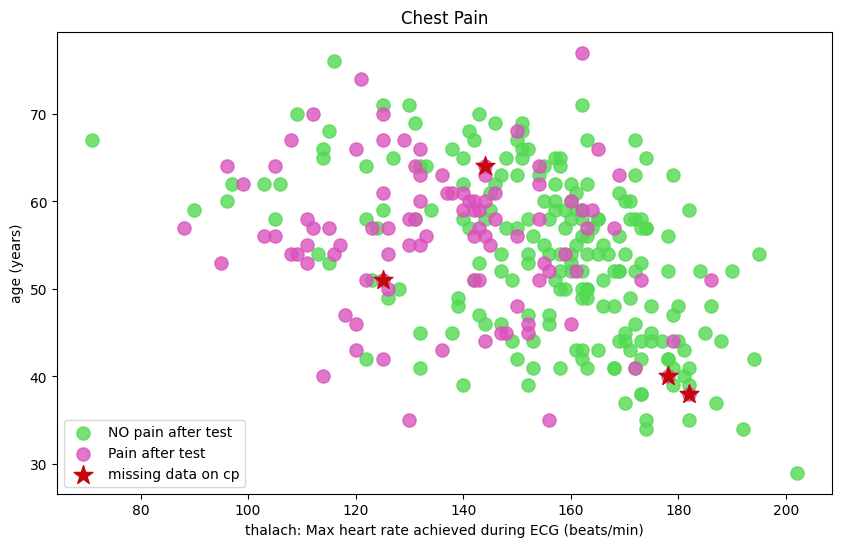

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

df_0 = df_new["exang"]== 0 # no pain
df_1 = df_new["exang"]== 1 # pain


ax.scatter(df_new.loc[df_0,"thalach"],df_new.loc[df_0,"age"],color="#53DA53",alpha=0.8,s= 90,label="NO pain after test")
ax.scatter(df_new.loc[df_1,"thalach"],df_new.loc[df_1,"age"],color="#DA53BD",alpha=0.8,s=90, label="Pain after test")

#outliers
missing = (df_new["exang"]==1) & (df_new["cp"]== 3)

ax.scatter(df_new.loc[missing,"thalach"],df_new.loc[missing, "age"],color="#C40707",s=200,marker="*",zorder=3,label="missing data on cp")
ax.set_xlabel("thalach: Max heart rate achieved during ECG (beats/min)")
ax.set_ylabel("age (years)")

ax.set_title("Chest Pain")
ax.legend(loc='lower left')
plt.show()



### What is missing? 
The starred points are the points that DID report a chest pain (`exang`== 1) after the stress test, however the `cp` column stated them as Asymptotic.

#### **A patient with low thalach + exercise angina + big oldpeak + downsloping ST is textbook oxygen-starved heart**


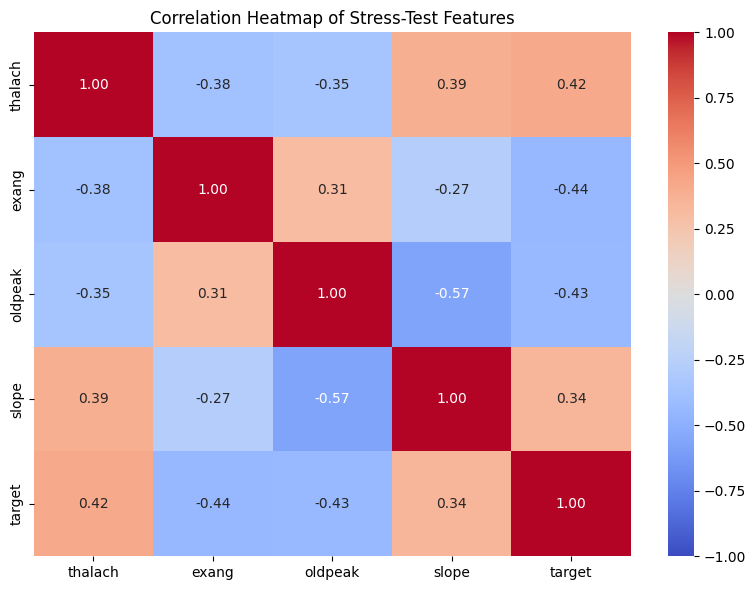

In [18]:
# make scatter plots with different sizes of scatters to show severness


stress_columns = ["thalach", "exang", "oldpeak", "slope", "target"]

corr = df_new[stress_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1,center=0)

plt.title("Correlation Heatmap of Stress-Test Features")
plt.tight_layout()
plt.show()

- I expect to see a **negative correlation** between `thalach` and `target` because higher levels of thalach are supposed to be health and the target  = 1 refers to presence of disease. However the data shows a positive correlation (0.42) which is odd.
- I expect to see **positive correlation** between `exang` and target, but it states -0.44.
- I expect to see **positive correlation** between `oldpeak` and targe, but it states -0.43.
- I expect to see **positive correlation** between `slop` and target with uplowping being the healtiest and downsloping being the least healthy, and there is a correlation of 0.34.

### Exploration of the remaining risk factors (not dignostics)

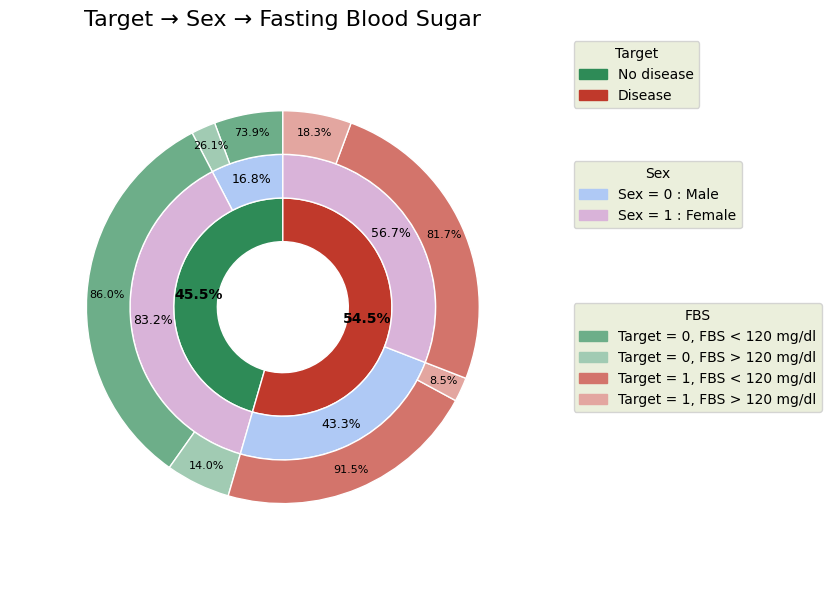

In [52]:
def lighten_color(color, amount=0.5):
    rgb = mcolors.to_rgb(color)
    return tuple(1 - amount * (1 - c) for c in rgb)

# Target colors
target_0 = colors["no_disease"]
target_1 = colors["disease"]

# Middle ring: sex
sex_0_color = "#AFC9F5"      # light blue
sex_1_color = "#D9B3D9"      # light purple

# colors for outer ring
light_no_disease = lighten_color(colors["no_disease"], 0.45)
light_disease = lighten_color(colors["disease"], 0.45)

lighter_no_disease = lighten_color(colors["no_disease"], 0.7)
lighter_disease = lighten_color(colors["disease"], 0.7)

fig, ax = plt.subplots(figsize=(8,6))

# inner ring : target

target_counts = df_new["target"].value_counts().sort_index()

target_values = [
    target_counts.get(0, 0),
    target_counts.get(1, 0)
]

wedges1, _ = ax.pie(
    target_values,
    radius=0.5,
    colors=[target_0, target_1],
    wedgeprops=dict(width=0.2, edgecolor="white"),
    startangle=90
)


# Add target percentages
total = sum(target_values)

for wedge, value in zip(wedges1, target_values):

    percentage = value / total * 100

    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 0.39 * np.cos(np.deg2rad(angle))
    y = 0.39 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        f"{percentage:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )


# middle ring: sex

sex_counts = df_new.groupby(["target", "sex"]).size()

middle_values = []
middle_colors = []
middle_percentages = []

for target in [0, 1]:

    target_total = target_counts.get(target, 0)

    for sex in [0, 1]:

        count = sex_counts.get((target, sex), 0)

        middle_values.append(count)

        # Conditional percentage:
        # sex percentage WITHIN target
        if target_total > 0:
            middle_percentages.append(count / target_total * 100)
        else:
            middle_percentages.append(0)

        if sex == 0:
            middle_colors.append(sex_0_color)
        else:
            middle_colors.append(sex_1_color)


wedges2, _ = ax.pie(
    middle_values,
    radius=0.7,
    colors=middle_colors,
    wedgeprops=dict(width=0.2, edgecolor="white"),
    startangle=90
)


# Add middle-ring percentages
for wedge, percentage in zip(wedges2, middle_percentages):

    angle = (wedge.theta1 + wedge.theta2) / 2

    # radius where the text will be placed
    r = 0.60

    x = r * np.cos(np.deg2rad(angle))
    y = r * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        f"{percentage:.1f}%",
        ha="center",
        va="center",
        fontsize=9
    )


# outer ring : fbs

fbs_counts = df_new.groupby(["target", "sex", "fbs"]).size()

outer_values = []
outer_colors = []
outer_percentages = []

for target in [0, 1]:
    for sex in [0, 1]:

        # Parent group = target + sex
        parent_total = sex_counts.get((target, sex), 0)

        for fbs in [0, 1]:

            count = fbs_counts.get((target, sex, fbs), 0)

            outer_values.append(count)

            # Conditional percentage:
            # FBS percentage WITHIN target + sex
            if parent_total > 0:
                outer_percentages.append(count / parent_total * 100)
            else:
                outer_percentages.append(0)

            # Color based on target
            # with different shades for FBS
            if target == 0:

                if fbs == 0:
                    outer_colors.append(lighter_no_disease)
                else:
                    outer_colors.append(light_no_disease)

            else:

                if fbs == 0:
                    outer_colors.append(lighter_disease)
                else:
                    outer_colors.append(light_disease)


wedges3, _ = ax.pie(
    outer_values,
    radius=0.9,
    colors=outer_colors,
    wedgeprops=dict(width=0.2, edgecolor="white"),
    startangle=90
)


# Add outer-ring percentages
for wedge, percentage in zip(wedges3, outer_percentages):

    angle = (wedge.theta1 + wedge.theta2) / 2

    # radius where percentage is placed
    r = 0.81

    x = r * np.cos(np.deg2rad(angle))
    y = r * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        f"{percentage:.1f}%",
        ha="center",
        va="center",
        fontsize=8
    )

# Target legend
target_handles = [
    plt.Rectangle((0, 0), 1, 1, color=target_0),
    plt.Rectangle((0, 0), 1, 1, color=target_1)
]

legend1 = ax.legend(
    target_handles,
    ["No disease", "Disease"],
    title="Target",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    facecolor = "#E7ECD4"
)

ax.add_artist(legend1)


# Sex legend
sex_handles = [
    plt.Rectangle((0, 0), 1, 1, color=sex_0_color),
    plt.Rectangle((0, 0), 1, 1, color=sex_1_color)
]

legend2 = ax.legend(
    sex_handles,
    ["Sex = 0 : Male", "Sex = 1 : Female"],
    title="Sex",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.78),
    facecolor = "#E7ECD4"
)

ax.add_artist(legend2)


# FBS legend
fbs_handles = [
    plt.Rectangle((0, 0), 1, 1, color=lighter_no_disease),
    plt.Rectangle((0, 0), 1, 1, color=light_no_disease),
    plt.Rectangle((0, 0), 1, 1, color=lighter_disease),
    plt.Rectangle((0, 0), 1, 1, color=light_disease)
]

legend3 = ax.legend(
    fbs_handles,
    [
        "Target = 0, FBS < 120 mg/dl",
        "Target = 0, FBS > 120 mg/dl",
        "Target = 1, FBS < 120 mg/dl",
        "Target = 1, FBS > 120 mg/dl"
    ],
    title="FBS",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.52),
    facecolor = "#E7ECD4"
)


ax.set_title("Target → Sex → Fasting Blood Sugar",fontsize=16,loc="center")


plt.tight_layout()
plt.show()

- It is shown that the percentage of females with heart disease is more that males (56.7% > 43.3%). This is limited to this dataset and contradictory to the general saying that heart disease is more common among men than women. By taking a look at the Healthy side of the chart we find out that our dataset consists more of female than men.(both health and diseased)
- On the healthy side, I expect to see higher percentages of `FBS < 120` in both men and women. The plot shows this exactly as 86% of healthy women and around 74% of healthy men have FBS <120.
- On the diseased side, I expect to see higher percentages of `FBS > 120` in both men and women. but it is only 8.5% among men and 18.3% among women. This could suggent that this feature os a bit noisy on the diseased side.